# Sección 6 (parte B): curvas de pérdida del baseline TF-IDF + regresión logística

In [1]:
import json, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.exceptions import ConvergenceWarning
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss

import clasificacion as C

RESULTS = Path("results"); FIGS = RESULTS / "figs"; FIGS.mkdir(parents=True, exist_ok=True)
pd.options.display.float_format = "{:.4f}".format
warnings.filterwarnings("ignore", category=ConvergenceWarning)

SEED = 42
# C elegido en validación por clasificacion_agnews.ipynb (si ese resultado no existe, 10)
C_REG = json.load(open(RESULTS / "clasificacion_B.json"))["tfidf"]["C"] if (RESULTS / "clasificacion_B.json").exists() else 10
print("C =", C_REG)

C = 10


In [2]:
D = C.load_agnews(val_frac=0.1, seed=SEED)


def uni_bi(toks):
    return toks + [a + " " + b for a, b in zip(toks, toks[1:])]


tfidf = TfidfVectorizer(analyzer=uni_bi, min_df=2, sublinear_tf=True)
Xtr = tfidf.fit_transform(D["train_tok"]); Xva = tfidf.transform(D["val_tok"])
ytr, yva = D["train_y"], D["val_y"]
print(f"{Xtr.shape[0]:,} documentos de entrenamiento x {Xtr.shape[1]:,} características")

/Users/marinesgarcia/Documents/UVG/DL/venv-lab7/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/marinesgarcia/Documents/UVG/DL/venv-lab7/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


108,000 documentos de entrenamiento x 428,247 características


In [3]:
CHECKPOINTS = [1, 2, 3, 5, 8, 12, 20, 30, 50, 75, 100, 150, 200, 300, 400]      # iteraciones acumuladas de L-BFGS
clf = LogisticRegression(C=C_REG, max_iter=1, warm_start=True)
hist, done, t_total = [], 0, 0.0
for k in CHECKPOINTS:
    clf.max_iter = k - done
    t0 = time.perf_counter(); clf.fit(Xtr, ytr); t_total += time.perf_counter() - t0
    done = k
    ptr, pva = clf.predict_proba(Xtr), clf.predict_proba(Xva)
    m = C.metrics(yva, pva.argmax(1))
    hist.append(dict(iteracion=k, train_loss=log_loss(ytr, ptr), val_loss=log_loss(yva, pva), val_acc=m["acc"], val_f1=m["f1"],
                     train_acc=float((ptr.argmax(1) == ytr).mean()), tiempo_acumulado_s=t_total))
hist = pd.DataFrame(hist)
hist

,iteracion,train_loss,val_loss,val_acc,val_f1,train_acc,tiempo_acumulado_s
0,1,0.9953,0.9833,0.8463,0.8442,0.8499,0.2779
1,2,0.9925,0.9803,0.8522,0.8511,0.8550,0.5983
2,3,0.9889,0.9768,0.8437,0.8411,0.8465,0.8912
3,5,0.9636,0.9505,0.8317,0.8322,0.8280,1.3900
4,8,0.7022,0.6909,0.7469,0.7457,0.7366,2.0123
5,12,0.4162,0.4125,0.8755,0.8751,0.8781,2.5160
6,20,0.2813,0.3147,0.9010,0.9008,0.9166,3.7009
7,30,0.2414,0.2829,0.9163,0.9160,0.9311,5.1257
8,50,0.1269,0.2474,0.9186,0.9184,0.9712,7.8700
9,75,0.0982,0.2342,0.9277,0.9275,0.9773,11.5020


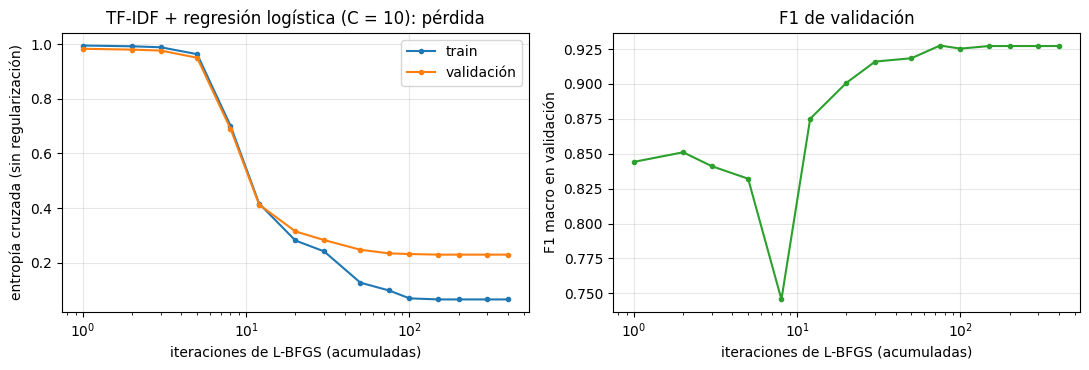

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].plot(hist.iteracion, hist.train_loss, "o-", ms=3, label="train"); ax[0].plot(hist.iteracion, hist.val_loss, "o-", ms=3, label="validación")
ax[0].set_xscale("log"); ax[0].set_xlabel("iteraciones de L-BFGS (acumuladas)"); ax[0].set_ylabel("entropía cruzada (sin regularización)")
ax[0].set_title(f"TF-IDF + regresión logística (C = {C_REG}): pérdida"); ax[0].legend(); ax[0].grid(alpha=0.3)
ax[1].plot(hist.iteracion, hist.val_f1, "o-", ms=3, color="tab:green"); ax[1].set_xscale("log")
ax[1].set_xlabel("iteraciones de L-BFGS (acumuladas)"); ax[1].set_ylabel("F1 macro en validación"); ax[1].set_title("F1 de validación"); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.savefig(FIGS / "baseline_tfidf_curvas_perdida.png", dpi=130); plt.show()

In [5]:
# Comparación con el baseline de una sola corrida (el de clasificacion_agnews.ipynb)
t0 = time.perf_counter()
full = LogisticRegression(C=C_REG, max_iter=2000).fit(Xtr, ytr)
t_full = time.perf_counter() - t0
mf = C.metrics(yva, full.predict_proba(Xva).argmax(1))
print(f"Corrida única: {full.n_iter_[0]} iteraciones, {t_full:.0f}s | val log-loss {log_loss(yva, full.predict_proba(Xva)):.4f} | val F1 {mf['f1']:.4f}")
print(f"Curva (última fila, {int(hist.iteracion.iloc[-1])} iteraciones): val log-loss {hist.val_loss.iloc[-1]:.4f} | val F1 {hist.val_f1.iloc[-1]:.4f}")
mejor_val = hist.loc[hist.val_loss.idxmin()]
print(f"Mínimo de la pérdida de validación en la curva: {mejor_val.val_loss:.4f} (iteración {int(mejor_val.iteracion)}), "
      f"pérdida de train en ese punto: {mejor_val.train_loss:.4f}")

Corrida única: 157 iteraciones, 24s | val log-loss 0.2302 | val F1 0.9274
Curva (última fila, 400 iteraciones): val log-loss 0.2295 | val F1 0.9272
Mínimo de la pérdida de validación en la curva: 0.2295 (iteración 150), pérdida de train en ese punto: 0.0655


In [6]:
json.dump(dict(
    modelo="TF-IDF (unigramas+bigramas, min_df=2, sublinear_tf) + LogisticRegression multinomial (L-BFGS)",
    config=dict(C=C_REG, n_features=int(Xtr.shape[1]), n_train=int(Xtr.shape[0]), n_val=int(Xva.shape[0]), split_seed=SEED,
                perdida="entropía cruzada de los datos, sin término de regularización"),
    curva_por_iteracion_lbfgs=hist.to_dict(orient="records"),
    corrida_unica=dict(n_iter=int(full.n_iter_[0]), tiempo_s=t_full, val_f1=mf["f1"], val_loss=float(log_loss(yva, full.predict_proba(Xva)))),
    fuente_notebook="baseline_tfidf_curvas.ipynb",
), open(RESULTS / "baseline_curvas.json", "w"), indent=1, default=float)
print("Guardado en", RESULTS / "baseline_curvas.json")

Guardado en results/baseline_curvas.json
